In [1]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [3]:
!nvidia-smi

Mon Mar 16 09:02:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P0             26W /   70W |     105MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import tensorflow as tf
tf.test.gpu_device_name()


'/device:GPU:0'

In [4]:
!git clone https://github.com/Akshatha-22/Calibration-Confidence.git



Cloning into 'Calibration-Confidence'...
remote: Enumerating objects: 155, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (117/117), done.
remote: Total 155 (delta 49), reused 123 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (155/155), 6.22 MiB | 26.01 MiB/s, done.
Resolving deltas: 100% (49/49), done.


In [9]:
%cd /content/Calibration-Confidence/

/content/Calibration-Confidence


In [10]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.6 MB/s eta 0:00:00


In [28]:
from google.colab import files
import os

figures_dir = 'results/figures'
all_image_files = [f for f in os.listdir(figures_dir) if f.endswith('.png')]

print(f"Downloading {len(all_image_files)} image files from '{figures_dir}':")

for img_file in all_image_files:
    file_path = os.path.join(figures_dir, img_file)
    try:
        files.download(file_path)
        print(f" - Successfully downloaded: {img_file}")
    except Exception as e:
        print(f" - Failed to download {img_file}: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 - Successfully downloaded: tag_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

 - Successfully downloaded: regression_reliability_diagram_for_first_results.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 - Successfully downloaded: category_distribution.png


Alternatively, you can manually download files:

1.  **Open the File Browser**: Click the folder icon on the left sidebar in Colab.
2.  **Navigate**: Go to the `Calibration-Confidence/results/figures` directory.
3.  **Download**: Right-click on the desired image file (e.g., `tag_distribution.png`) and select 'Download'.

All image files in 'results/figures':
 - tag_distribution.png
 - content_length_distribution.png
 - regression_reliability_diagram_for_first_results.png
 - category_distribution.png

Displaying all image files:
Displaying: tag_distribution.png


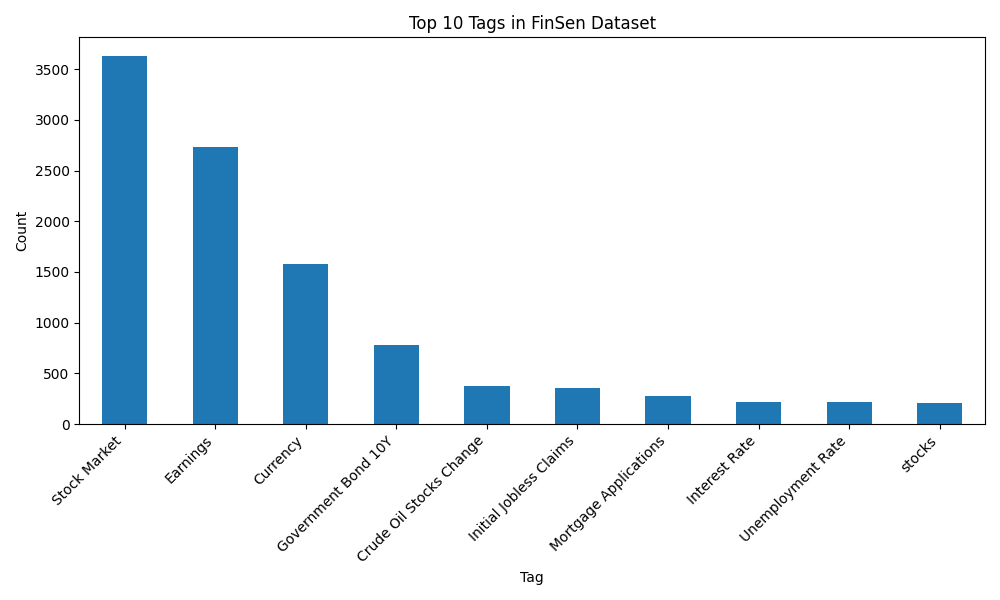

Displaying: content_length_distribution.png


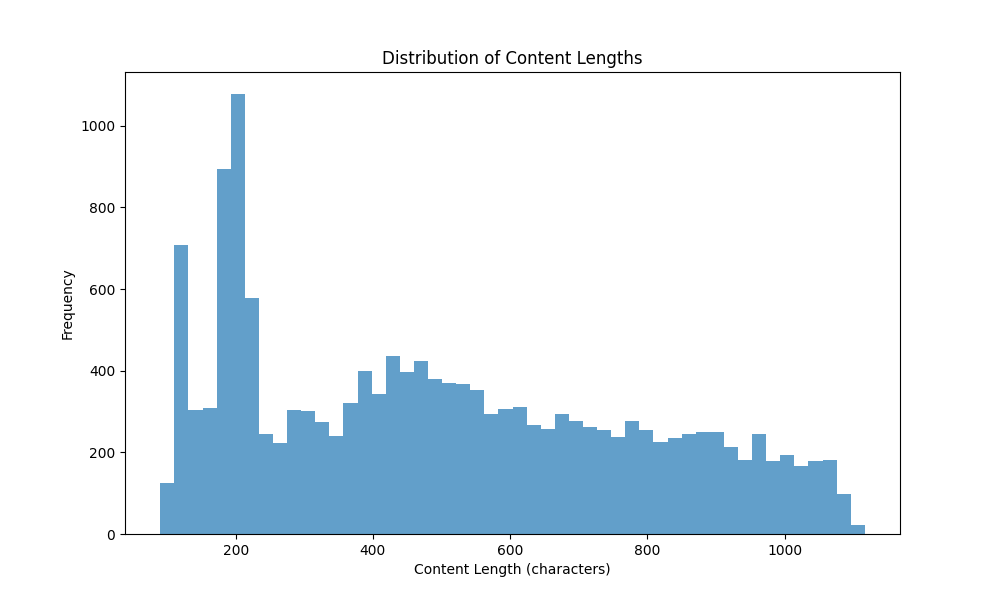

Displaying: regression_reliability_diagram_for_first_results.png


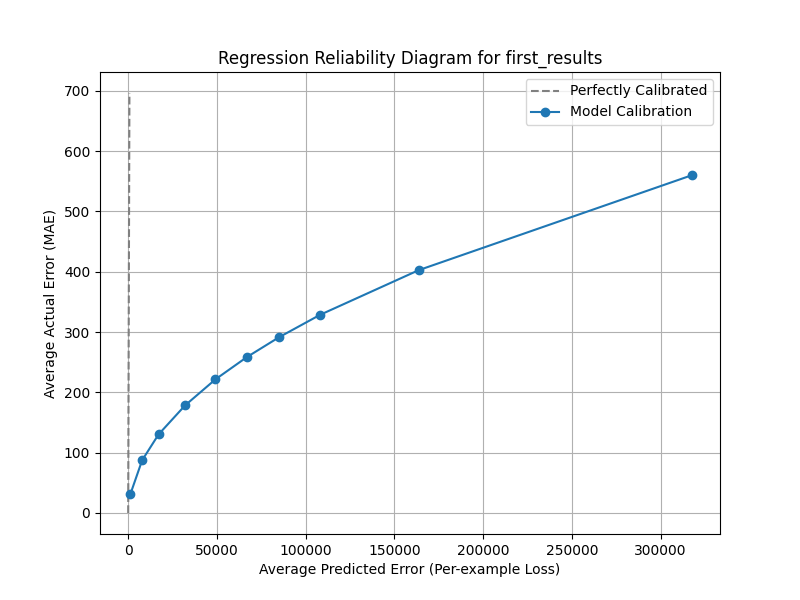

Displaying: category_distribution.png


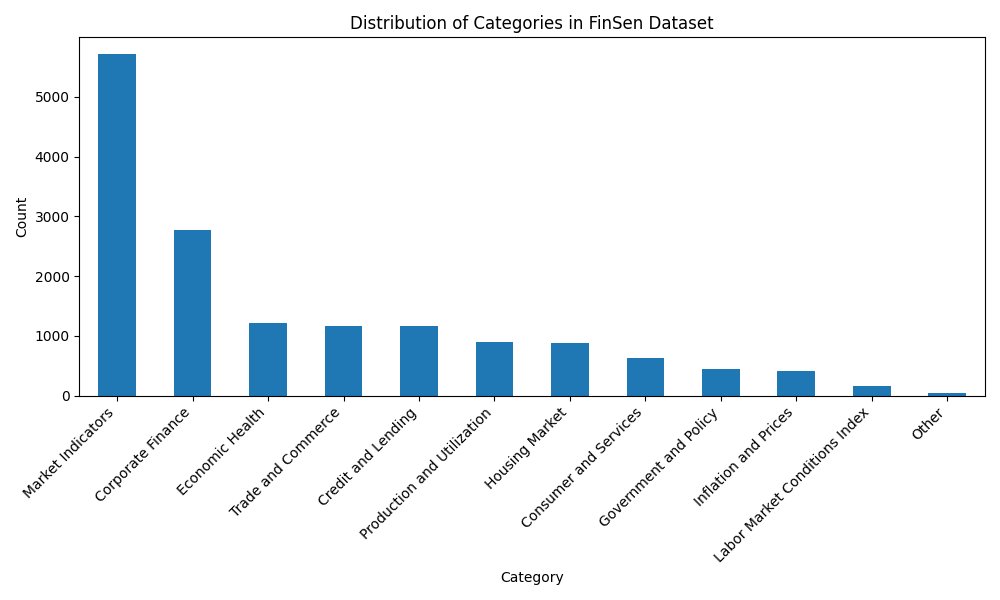

In [27]:
import os
from IPython.display import Image, display

figures_dir = 'results/figures'
all_image_files = [f for f in os.listdir(figures_dir) if f.endswith('.png')]

print(f"All image files in '{figures_dir}':")
for img_file in all_image_files:
    print(f" - {img_file}")

print("\nDisplaying all image files:")
for img_file in all_image_files:
    print(f"Displaying: {img_file}")
    display(Image(filename=os.path.join(figures_dir, img_file)))


In [14]:
import os
import sys
import torch

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# (Optional) install deps if needed
# !pip -q install -r requirements.txt

# Make sure repo root is on sys.path
ROOT = os.path.abspath(os.path.join(os.getcwd()))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

os.makedirs("results/checkpoints", exist_ok=True)
os.makedirs("results/figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

print("Ready.")

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Ready.


In [17]:
%run /content/Calibration-Confidence/notebooks/colab_training.ipynb

In [21]:
import os, glob

print("CWD:", os.getcwd())

print("\nCheckpoints:")
for p in sorted(glob.glob("results/checkpoints/*.pt")):
    print(" -", p)

print("\nResult files:")
for p in sorted(glob.glob("results/*_results.npz")):
    print(" -", p)

CWD: /content/Calibration-Confidence

Checkpoints:
 - results/checkpoints/deep.pt
 - results/checkpoints/lstm.pt
 - results/checkpoints/model.pt
 - results/checkpoints/residual.pt
 - results/checkpoints/rnn.pt
 - results/checkpoints/test_mlp.pt
 - results/checkpoints/test_mlp_es.pt
 - results/checkpoints/test_mlp_tb.pt

Result files:
 - results/first_results.npz
 - results/mlp_first_results.npz


Calculated ECE Score: 84927.8672


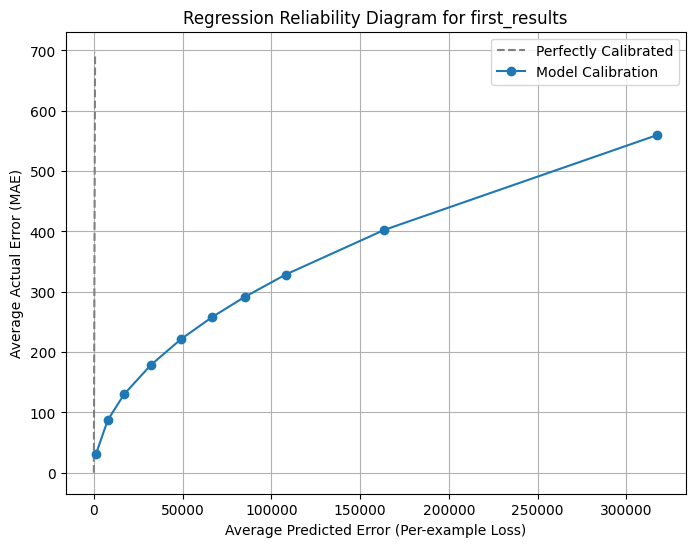

Reliability diagram saved to: results/figures/regression_reliability_diagram_for_first_results.png


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Load the data from the .npz file
result_file_path = 'results/first_results.npz'
with np.load(result_file_path) as data:
    predictions = data['predictions'].flatten()
    targets = data['targets'].flatten()
    per_example_loss = data['per_example_loss'].flatten()

# Calculate absolute errors
abs_errors = np.abs(predictions - targets)

def calculate_regression_ece(predicted_errors, actual_errors, num_bins=10):
    """Calculates ECE for regression based on predicted vs. actual errors."""
    # Sort by predicted_errors to create bins
    sorted_indices = np.argsort(predicted_errors)
    sorted_predicted_errors = predicted_errors[sorted_indices]
    sorted_actual_errors = actual_errors[sorted_indices]

    bin_boundaries = np.linspace(0, len(sorted_predicted_errors), num_bins + 1, dtype=int)
    ece = 0.0
    total_samples = len(predicted_errors)

    for i in range(num_bins):
        start_idx = bin_boundaries[i]
        end_idx = bin_boundaries[i+1]

        if start_idx == end_idx: # Empty bin
            continue

        bin_predicted_errors = sorted_predicted_errors[start_idx:end_idx]
        bin_actual_errors = sorted_actual_errors[start_idx:end_idx]

        avg_predicted_error = np.mean(bin_predicted_errors)
        avg_actual_error = np.mean(bin_actual_errors)

        bin_weight = len(bin_predicted_errors) / total_samples
        ece += bin_weight * np.abs(avg_predicted_error - avg_actual_error)

    return ece

def plot_regression_reliability_diagram(predicted_errors, actual_errors, num_bins=10, title="Regression Reliability Diagram"):
    """Plots a reliability diagram for regression."""
    plt.figure(figsize=(8, 6))

    # Sort by predicted_errors to create bins
    sorted_indices = np.argsort(predicted_errors)
    sorted_predicted_errors = predicted_errors[sorted_indices]
    sorted_actual_errors = actual_errors[sorted_indices]

    bin_boundaries = np.linspace(0, len(sorted_predicted_errors), num_bins + 1, dtype=int)

    bin_avg_predicted_errors = []
    bin_avg_actual_errors = []

    for i in range(num_bins):
        start_idx = bin_boundaries[i]
        end_idx = bin_boundaries[i+1]

        if start_idx == end_idx: # Empty bin
            continue

        bin_predicted_errors = sorted_predicted_errors[start_idx:end_idx]
        bin_actual_errors = sorted_actual_errors[start_idx:end_idx]

        bin_avg_predicted_errors.append(np.mean(bin_predicted_errors))
        bin_avg_actual_errors.append(np.mean(bin_actual_errors))

    plt.plot([0, np.max(actual_errors)], [0, np.max(actual_errors)], "--", color="gray", label="Perfectly Calibrated")
    plt.plot(bin_avg_predicted_errors, bin_avg_actual_errors, "o-", label="Model Calibration")

    plt.xlabel("Average Predicted Error (Per-example Loss)")
    plt.ylabel("Average Actual Error (MAE)")
    plt.title(title)
    plt.legend()
    plt.grid(True)

    # Ensure the figures directory exists
    os.makedirs('results/figures', exist_ok=True)
    fig_path = os.path.join('results/figures', title.replace(' ', '_').lower() + '.png')
    plt.savefig(fig_path)
    plt.show()
    return fig_path

# Calculate ECE score
ece_score = calculate_regression_ece(per_example_loss, abs_errors)
print(f"Calculated ECE Score: {ece_score:.4f}")

# Plot Reliability Diagram
reliability_diagram_path = plot_regression_reliability_diagram(per_example_loss, abs_errors, title="Regression Reliability Diagram for first_results")
print(f"Reliability diagram saved to: {reliability_diagram_path}")

In [25]:
import numpy as np
import os

# Assuming results/first_results.npz contains the relevant data
result_file_path = 'results/first_results.npz'

if os.path.exists(result_file_path):
    with np.load(result_file_path) as data:
        print(f"Contents of {result_file_path}:")
        for key in data.keys():
            print(f" - {key}: {data[key].shape} (dtype: {data[key].dtype})")
            # Print a snippet of the data for better understanding
            if data[key].size > 0:
                print(f"   Sample data: {data[key].flatten()[:5]}")
            else:
                print("   (Empty array)")
else:
    print(f"Error: {result_file_path} not found. Please ensure the training process generated this file.")


Contents of results/first_results.npz:
 - predictions: (456, 1) (dtype: float32)
   Sample data: [537.98505 416.0312  451.23196 389.70428 429.05182]
 - targets: (456, 1) (dtype: float32)
   Sample data: [606. 118. 183. 505. 346.]
 - per_example_loss: (456, 1) (dtype: float32)
   Sample data: [ 4626.0337 88822.586  71948.38   13293.102   6897.6045]


This will show us the keys within the `.npz` file and give us an idea of what kind of data is stored, which is crucial for plotting reliability diagrams and calculating ECE scores. Based on the output, we can then proceed with generating the plots and calculations.

In [24]:
import os

drive_path = '/content/drive/MyDrive/'

print(f"Contents of {drive_path}:")
for item in os.listdir(drive_path):
    print(f" - {item}")

if 'calibration_confidence_results.zip' in os.listdir(drive_path):
    print("\n'calibration_confidence_results.zip' found in Google Drive.")
else:
    print("\n'calibration_confidence_results.zip' NOT found in Google Drive.")

Contents of /content/drive/MyDrive/:
 - Colab Notebooks
 - ISI_DATASCIENCE_PROJECT
 - Saved from the Google app
 - calibration_confidence_results.zip

'calibration_confidence_results.zip' found in Google Drive.


In [22]:
import os

print("Contents of results directory:")
for root, dirs, files in os.walk('results'):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))


Contents of results directory:
results/first_results.npz
results/mlp_first_results.npz
results/figures
results/checkpoints
results/figures/tag_distribution.png
results/figures/content_length_distribution.png
results/figures/category_distribution.png
results/checkpoints/residual.pt
results/checkpoints/test_mlp_es.pt
results/checkpoints/model.pt
results/checkpoints/rnn.pt
results/checkpoints/deep.pt
results/checkpoints/test_mlp_tb.pt
results/checkpoints/test_mlp.pt
results/checkpoints/lstm.pt


In [23]:
import shutil

# Create a zip archive of the results directory
shutil.make_archive('calibration_confidence_results', 'zip', 'results')

# Define the destination path in Google Drive
drive_path = '/content/drive/MyDrive/calibration_confidence_results.zip'

# Copy the zip file to Google Drive
shutil.copy('calibration_confidence_results.zip', drive_path)

print(f"Results successfully saved to: {drive_path}")


Results successfully saved to: /content/drive/MyDrive/calibration_confidence_results.zip


Displaying: tag_distribution.png


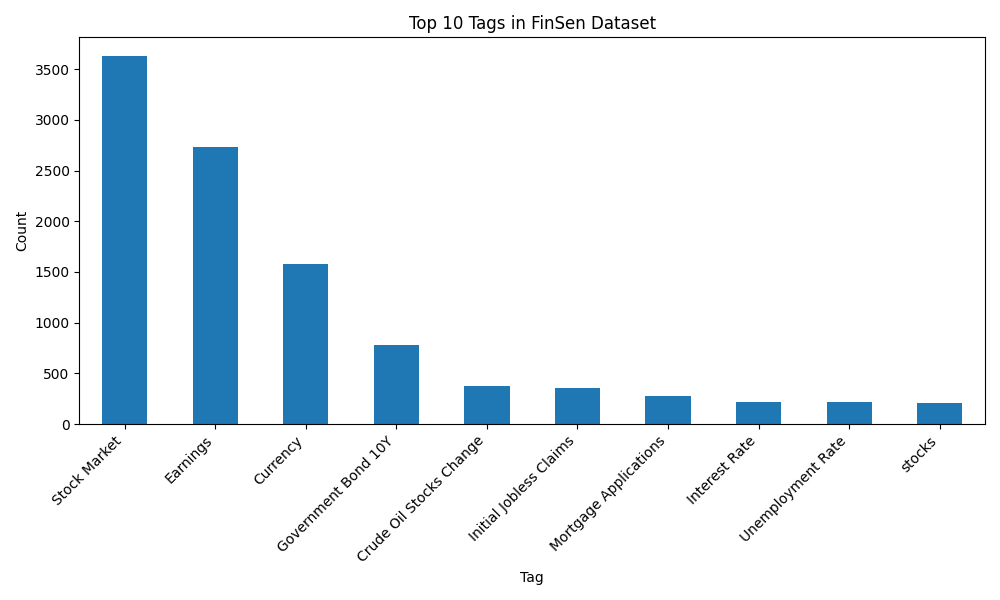

Displaying: content_length_distribution.png


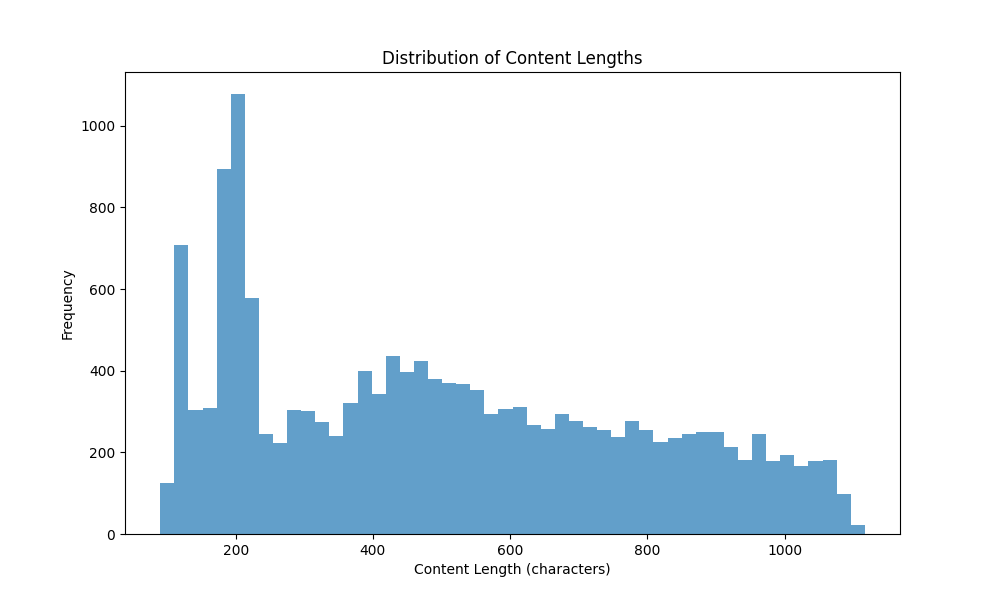

Displaying: category_distribution.png


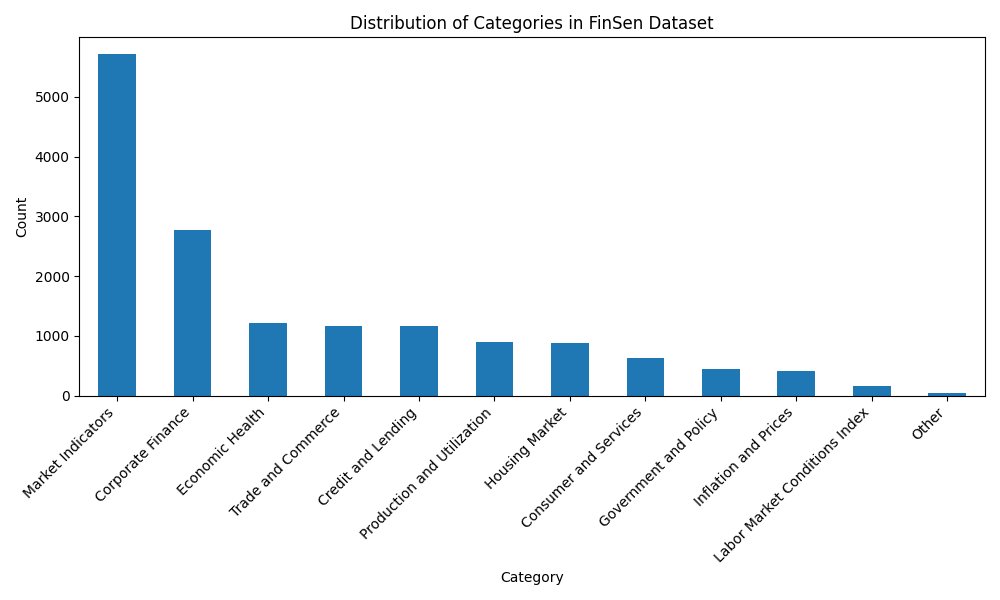

In [20]:
from IPython.display import Image, display

image_files = ['tag_distribution.png', 'content_length_distribution.png', 'category_distribution.png']

for img_file in image_files:
    print(f"Displaying: {img_file}")
    display(Image(filename=os.path.join('results/figures', img_file)))


In [19]:
import os
print(os.listdir('results/figures'))

['tag_distribution.png', 'content_length_distribution.png', 'category_distribution.png']


In [18]:
import os
print(os.listdir('results/checkpoints'))

['residual.pt', 'test_mlp_es.pt', 'model.pt', 'rnn.pt', 'deep.pt', 'test_mlp_tb.pt', 'test_mlp.pt', 'lstm.pt']
